In [ ]:
!pip install shapely pyproj folium

  Using cached shapely-2.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
  Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 28.4 MB/s eta 0:00:00


README:

chunk 1 uses aryans code and gets the polygons/points.
chunk 2 plots the polygons and points.
chunk 3 and 4 are my dummy machine learning model they take ages to run but make the screenshots i sent on discord.
chunk 5 shows the sample areas for urban/nonurban used in chunk 6
chunk 6 gets the tiles for positive and negative.
chunk 7 deletes the images. the images are stored in content/images/nonurban or urban.

In [ ]:
from arcgis.gis import GIS
from arcgis.features import FeatureLayer
from shapely.geometry import Polygon, Point
from pyproj import Transformer
import folium

gis = GIS()

# URLs
polygon_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/2"
points_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/0"

polygon_layer = FeatureLayer(polygon_url)
points_layer = FeatureLayer(points_url)

# Fetch features
polygons = polygon_layer.query(where="1=1", out_fields="*", result_record_count=2000).features
points = points_layer.query(where="1=1", out_fields="dateoccurence", result_record_count=2000).features

# Transformer from NZTM2000 (EPSG:2193) to WGS84 lat/lon (EPSG:4326)
transformer = Transformer.from_crs("epsg:2193", "epsg:4326", always_xy=True)

# Convert polygons to Shapely polygons (lon, lat)
polygon_shapes = []
for poly in polygons:
    for ring in poly.geometry['rings']:
        # Transform coordinates correctly
        coords_lonlat = [transformer.transform(x, y) for x, y in ring]  # (lon, lat)
        polygon_shapes.append((Polygon(coords_lonlat), poly.attributes))

# Convert points to Shapely points (lon, lat)
point_shapes = []
for pt in points:
    x, y = pt.geometry['x'], pt.geometry['y']
    lon, lat = transformer.transform(x, y)
    point_shapes.append((Point(lon, lat), pt.attributes.get("dateoccurence", "Unknown")))

# Spatial join: points inside polygons
polygon_dates = []
for poly, attrs in polygon_shapes:
    dates_inside = [date for pt, date in point_shapes if poly.contains(pt)]
    polygon_dates.append((poly, dates_inside))

# Create Folium map centered on first polygon
first_coords = list(polygon_shapes[0][0].exterior.coords)[0]
m = folium.Map(location=[first_coords[1], first_coords[0]], zoom_start=10)  # lat, lon

# Plot polygons with popup showing dates
for i, (poly, dates) in enumerate(polygon_dates):
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in poly.exterior.coords],
        color='red',
        weight=3,
        fill=True,
        fill_color='red',
        fill_opacity=0.5,
        popup=f"Polygon {i+1}\nDates: {', '.join(dates) if dates else 'No landslides'}"
    ).add_to(m)

    # Add satellite tile layer
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Satellite',
    overlay=False,
    control=True
).add_to(m)

# Plot points as small green markers
for pt, date in point_shapes[:100]:
    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=4,
        color='green',
        fill=True,
        fill_color='green',
        fill_opacity=0.8,
        popup=str(date)
    ).add_to(m)

# Add a simple legend
legend_html = '''
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 180px; height: 90px;
    background-color: white; z-index:9999; font-size:14px;
    border:2px solid grey; border-radius:5px; padding: 10px;
">
<b>Landslide Legend</b><br>
<span style="background-color:red;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Polygon<br>
<span style="background-color:green;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Point
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m



In [ ]:
import ee
from arcgis.gis import GIS
from arcgis.features import FeatureLayer
from shapely.geometry import Polygon, Point, box
from pyproj import Transformer
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import requests
from io import BytesIO
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage import feature, color
from skimage.transform import resize
import pickle
import warnings
warnings.filterwarnings('ignore')

# Initialize Earth Engine
print("Initializing Google Earth Engine...")
ee.Authenticate()
ee.Initialize(project='andy-geog761')
print("✓ Earth Engine initialized successfully!\n")

# Set matplotlib to display inline
%matplotlib inline
plt.style.use('default')

gis = GIS()

# URLs
polygon_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/2"
points_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/0"

polygon_layer = FeatureLayer(polygon_url)
points_layer = FeatureLayer(points_url)

print("Fetching landslide data from ArcGIS...")
# Fetch features
polygons = polygon_layer.query(where="1=1", out_fields="*", result_record_count=2000).features
points = points_layer.query(where="1=1", out_fields="dateoccurence", result_record_count=2000).features

print(f"Total polygons fetched: {len(polygons)}")
print(f"Total points fetched: {len(points)}")

# Transformer from NZTM2000 (EPSG:2193) to WGS84 lat/lon (EPSG:4326)
transformer = Transformer.from_crs("epsg:2193", "epsg:4326", always_xy=True)

# Convert polygons to Shapely polygons
polygon_shapes = []
for poly in polygons:
    for ring in poly.geometry['rings']:
        coords_lonlat = [transformer.transform(x, y) for x, y in ring]
        polygon_shapes.append((Polygon(coords_lonlat), poly.attributes))

# Your specified bounding box (lon, lat)
waitakere_bounds = {
    'min_lon': 174.524517,
    'max_lon': 174.594898,
    'min_lat': -36.988837,
    'max_lat': -36.932974
}

# Filter polygons in your specified area
waitakere_polygons = []
for poly, attrs in polygon_shapes:
    centroid = poly.centroid
    if (waitakere_bounds['min_lon'] <= centroid.x <= waitakere_bounds['max_lon'] and
        waitakere_bounds['min_lat'] <= centroid.y <= waitakere_bounds['max_lat']):
        waitakere_polygons.append((poly, attrs))

print(f"\n{'='*70}")
print(f"Found {len(waitakere_polygons)} polygons in specified area")
print(f"Area: {waitakere_bounds['min_lon']:.6f}°E to {waitakere_bounds['max_lon']:.6f}°E")
print(f"      {abs(waitakere_bounds['max_lat']):.6f}°S to {abs(waitakere_bounds['min_lat']):.6f}°S")
print(f"{'='*70}\n")

# Sort by size for better visualization
selected_polygons = sorted(waitakere_polygons, key=lambda x: x[0].area, reverse=True)

# Define area of interest for high-res imagery
aoi = ee.Geometry.Rectangle([
    waitakere_bounds['min_lon'],
    waitakere_bounds['min_lat'],
    waitakere_bounds['max_lon'],
    waitakere_bounds['max_lat']
])

# Use Planet SkySat (0.5m resolution) or NAIP (1m resolution) or high-res Maxar imagery
# For New Zealand, we'll use the highest resolution available in GEE
print("Loading high-resolution imagery from Google Earth Engine...")

# Try multiple high-resolution sources
# 1. First try: Maxar/DigitalGlobe imagery (0.3-0.5m resolution)
try:
    highres = ee.ImageCollection('projects/google/ar_and_cc/maxar') \
        .filterBounds(aoi) \
        .filterDate('2020-01-01', '2024-12-31') \
        .sort('system:time_start', False)

    if highres.size().getInfo() > 0:
        latest_image = highres.first()
        image_source = "Maxar (0.3-0.5m resolution)"
        rgb_bands = ['R', 'G', 'B']
        rgb_vis = {'min': 0, 'max': 255, 'bands': rgb_bands}
        print(f"✓ Using Maxar high-resolution imagery")
    else:
        raise Exception("No Maxar imagery available")
except:
    # 2. Fallback: Use Sentinel-2 with 10m resolution (best freely available)
    print("⚠️  Maxar not available, using Sentinel-2 10m resolution...")
    s2 = ee.ImageCollection('COPERNICUS/S2_SR') \
        .filterBounds(aoi) \
        .filterDate('2023-01-01', '2024-12-31') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .select(['B4', 'B3', 'B2', 'B8', 'B11'])  # R, G, B, NIR, SWIR

    latest_image = s2.sort('system:time_start', False).first()
    image_source = "Sentinel-2 (10m resolution)"
    rgb_bands = ['B4', 'B3', 'B2']
    rgb_vis = {'min': 0, 'max': 3000, 'bands': rgb_bands}

# Get image metadata
image_date = ee.Date(latest_image.get('system:time_start')).format('YYYY-MM-dd').getInfo()

print(f"✓ Image source: {image_source}")
print(f"✓ Image date: {image_date}\n")

# Split data into training and testing
np.random.seed(42)
train_ratio = 0.7
n_train = int(len(selected_polygons) * train_ratio)
indices = np.random.permutation(len(selected_polygons))
train_indices = indices[:n_train]
test_indices = indices[n_train:]

train_polygons = [selected_polygons[i] for i in train_indices]
test_polygons = [selected_polygons[i] for i in test_indices]

print(f"{'='*70}")
print(f"TRAIN/TEST SPLIT")
print(f"{'='*70}")
print(f"Total polygons: {len(selected_polygons)}")
print(f"Training set: {len(train_polygons)} polygons ({len(train_polygons)/len(selected_polygons)*100:.1f}%)")
print(f"Testing set: {len(test_polygons)} polygons ({len(test_polygons)/len(selected_polygons)*100:.1f}%)")
print(f"{'='*70}\n")

def get_thumbnail(image, region, vis_params, dimensions=512):
    """Get thumbnail URL from Earth Engine"""
    url = image.getThumbURL({
        'region': region,
        'dimensions': dimensions,
        'format': 'png',
        **vis_params
    })
    return url

def extract_features_from_image(img_array, polygon_mask=None):
    """Extract comprehensive features from imagery"""
    features = []

    # Convert to different color spaces
    if len(img_array.shape) == 3 and img_array.shape[2] >= 3:
        # RGB statistics
        for channel in range(min(3, img_array.shape[2])):
            channel_data = img_array[:, :, channel]
            if polygon_mask is not None:
                channel_data = channel_data[polygon_mask]
            features.extend([
                np.mean(channel_data),
                np.std(channel_data),
                np.median(channel_data),
                np.percentile(channel_data, 25),
                np.percentile(channel_data, 75)
            ])

        # Convert to HSV for additional features
        try:
            hsv = color.rgb2hsv(img_array[:, :, :3])
            for channel in range(3):
                channel_data = hsv[:, :, channel]
                if polygon_mask is not None:
                    channel_data = channel_data[polygon_mask]
                features.extend([
                    np.mean(channel_data),
                    np.std(channel_data)
                ])
        except:
            features.extend([0] * 6)

        # Texture features using GLCM
        try:
            gray = color.rgb2gray(img_array[:, :, :3])
            gray_uint = (gray * 255).astype(np.uint8)
            glcm = feature.graycomatrix(gray_uint, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                                       levels=256, symmetric=True, normed=True)
            features.extend([
                feature.graycoprops(glcm, 'contrast').mean(),
                feature.graycoprops(glcm, 'dissimilarity').mean(),
                feature.graycoprops(glcm, 'homogeneity').mean(),
                feature.graycoprops(glcm, 'energy').mean(),
                feature.graycoprops(glcm, 'correlation').mean()
            ])
        except:
            features.extend([0] * 5)
    else:
        features.extend([0] * 26)

    return np.array(features)

# Extract features for all polygons
print(f"{'='*70}")
print(f"EXTRACTING FEATURES FROM IMAGERY")
print(f"{'='*70}\n")

X_train = []
y_train = []
X_test = []
y_test = []

def process_polygon_set(polygon_list, dataset_name):
    """Process a set of polygons and extract features"""
    X_landslide = []
    X_non_landslide = []

    for i, (poly, attrs) in enumerate(polygon_list):
        print(f"Processing {dataset_name} polygon {i+1}/{len(polygon_list)}...", end='\r')

        bounds = poly.bounds
        centroid = poly.centroid

        # Create Earth Engine polygon
        coords_ee = [[lon, lat] for lon, lat in poly.exterior.coords]
        poly_ee = ee.Geometry.Polygon([coords_ee])

        # Buffer for context (200m)
        poly_buffered = poly_ee.buffer(200)

        # Clip image to polygon area
        clipped_image = latest_image.clip(poly_buffered)

        # Get thumbnail
        thumb_url = get_thumbnail(clipped_image, poly_buffered, rgb_vis, dimensions=512)

        try:
            response = requests.get(thumb_url, timeout=30)
            img = plt.imread(BytesIO(response.content))

            # Create polygon mask in image coordinates
            buffer_bounds = poly_buffered.bounds().getInfo()['coordinates'][0]
            min_lon = min([coord[0] for coord in buffer_bounds])
            max_lon = max([coord[0] for coord in buffer_bounds])
            min_lat = min([coord[1] for coord in buffer_bounds])
            max_lat = max([coord[1] for coord in buffer_bounds])

            img_height, img_width = img.shape[:2]

            # Create mask for landslide area
            mask = np.zeros((img_height, img_width), dtype=bool)
            for y in range(img_height):
                for x in range(img_width):
                    lon = min_lon + (x / img_width) * (max_lon - min_lon)
                    lat = max_lat - (y / img_height) * (max_lat - min_lat)
                    point = Point(lon, lat)
                    if poly.contains(point):
                        mask[y, x] = True

            # Extract features from landslide area (positive sample)
            features_landslide = extract_features_from_image(img, mask)
            X_landslide.append(features_landslide)

            # Create negative samples (non-landslide areas in the buffer)
            # Sample 2 random regions outside the landslide
            for _ in range(2):
                # Create random offset region
                offset_x = np.random.randint(0, img_width // 4)
                offset_y = np.random.randint(0, img_height // 4)
                size = min(img_width, img_height) // 4

                y1 = max(0, min(img_height - size, offset_y))
                y2 = y1 + size
                x1 = max(0, min(img_width - size, offset_x))
                x2 = x1 + size

                region = img[y1:y2, x1:x2]
                region_mask = mask[y1:y2, x1:x2]

                # Only use if it doesn't overlap significantly with landslide
                if np.sum(region_mask) < 0.1 * region_mask.size:
                    features_non = extract_features_from_image(region, None)
                    X_non_landslide.append(features_non)

        except Exception as e:
            print(f"\nWarning: Failed to process polygon {i+1}: {e}")
            continue

    print(f"\n✓ {dataset_name} set processed: {len(X_landslide)} landslide samples, {len(X_non_landslide)} non-landslide samples\n")

    return X_landslide, X_non_landslide

# Process training set
X_train_pos, X_train_neg = process_polygon_set(train_polygons, "Training")
X_train = X_train_pos + X_train_neg
y_train = [1] * len(X_train_pos) + [0] * len(X_train_neg)

# Process test set
X_test_pos, X_test_neg = process_polygon_set(test_polygons, "Testing")
X_test = X_test_pos + X_test_neg
y_test = [1] * len(X_test_pos) + [0] * len(X_test_neg)

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"{'='*70}")
print(f"TRAINING DATASET")
print(f"{'='*70}")
print(f"Training samples: {len(X_train)} ({np.sum(y_train)} landslide, {len(y_train) - np.sum(y_train)} non-landslide)")
print(f"Test samples: {len(X_test)} ({np.sum(y_test)} landslide, {len(y_test) - np.sum(y_test)} non-landslide)")
print(f"Feature vector size: {X_train.shape[1]}")
print(f"{'='*70}\n")

# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("✓ Model training complete!\n")

# Evaluate on training set
train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Evaluate on test set
test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"{'='*70}")
print(f"MODEL PERFORMANCE")
print(f"{'='*70}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy: {test_accuracy*100:.2f}%")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, test_pred, target_names=['Non-Landslide', 'Landslide']))

# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
print(f"\nConfusion Matrix (Test Set):")
print(f"                  Predicted")
print(f"                  Non-LS  Landslide")
print(f"Actual Non-LS     {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"Actual Landslide  {cm[1,0]:6d}  {cm[1,1]:6d}")

# Feature importance
feature_names = []
for i in range(3):
    feature_names.extend([f'RGB_Ch{i}_mean', f'RGB_Ch{i}_std', f'RGB_Ch{i}_median',
                         f'RGB_Ch{i}_q25', f'RGB_Ch{i}_q75'])
for i in range(3):
    feature_names.extend([f'HSV_Ch{i}_mean', f'HSV_Ch{i}_std'])
feature_names.extend(['GLCM_contrast', 'GLCM_dissimilarity', 'GLCM_homogeneity',
                     'GLCM_energy', 'GLCM_correlation'])

feature_importance = rf_model.feature_importances_
top_features_idx = np.argsort(feature_importance)[-10:][::-1]

print(f"\n{'='*70}")
print(f"TOP 10 MOST IMPORTANT FEATURES")
print(f"{'='*70}")
for idx in top_features_idx:
    print(f"{feature_names[idx]:25s}: {feature_importance[idx]:.4f}")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Feature Importance
ax = axes[0, 0]
top_10_features = [feature_names[i] for i in top_features_idx]
top_10_importance = [feature_importance[i] for i in top_features_idx]
ax.barh(range(len(top_10_features)), top_10_importance, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_10_features)))
ax.set_yticklabels(top_10_features, fontsize=9)
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Feature Importance', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Plot 2: Confusion Matrix Heatmap
ax = axes[0, 1]
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-Landslide', 'Landslide'])
ax.set_yticklabels(['Non-Landslide', 'Landslide'])
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center",
                      color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=20, fontweight='bold')
plt.colorbar(im, ax=ax)

# Plot 3: Train vs Test Accuracy
ax = axes[1, 0]
accuracies = [train_accuracy * 100, test_accuracy * 100]
labels = ['Training', 'Testing']
bars = ax.bar(labels, accuracies, color=['green', 'orange'], edgecolor='black', linewidth=2, alpha=0.7)
ax.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis='y')
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Plot 4: Training/Test Split Visualization
ax = axes[1, 1]
ax.axis('off')
summary_text = f"""
MODEL SUMMARY

Algorithm: Random Forest Classifier
Estimators: 200 trees
Max Depth: 20

Dataset Split:
• Training: {len(train_polygons)} polygons → {len(X_train)} samples
• Testing: {len(test_polygons)} polygons → {len(X_test)} samples

Feature Extraction:
• RGB statistics (mean, std, median, quartiles)
• HSV color space features
• Texture (GLCM): contrast, homogeneity, energy
• Total features: {X_train.shape[1]}

Performance:
• Training Accuracy: {train_accuracy*100:.1f}%
• Testing Accuracy: {test_accuracy*100:.1f}%

Image Source: {image_source}
Date: {image_date}

Model saved as: landslide_model.pkl
"""
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=11, family='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, pad=1.5))

plt.tight_layout()
plt.show()

# Save the model
model_filename = 'landslide_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump({
        'model': rf_model,
        'feature_names': feature_names,
        'image_source': image_source,
        'image_date': image_date,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy
    }, f)

print(f"\n{'='*70}")
print(f"✓ Model saved as: {model_filename}")
print(f"{'='*70}\n")

# Show predictions on test polygons
print(f"{'='*70}")
print(f"TEST SET PREDICTIONS")
print(f"{'='*70}\n")

for i, (poly, attrs) in enumerate(test_polygons[:5]):  # Show first 5 test polygons
    # Get the prediction for this polygon's features
    idx = i
    actual = "Landslide" if y_test[idx] == 1 else "Non-Landslide"
    predicted = "Landslide" if test_pred[idx] == 1 else "Non-Landslide"
    confidence = rf_model.predict_proba(X_test[idx:idx+1])[0]

    area_m2 = poly.area * 111000 * 111000
    print(f"Test Polygon {i+1}:")
    print(f"  Location: {poly.centroid.y:.5f}°S, {poly.centroid.x:.5f}°E")
    print(f"  Area: {area_m2:.0f} m²")
    print(f"  Actual: {actual}")
    print(f"  Predicted: {predicted} (confidence: {confidence[1]*100:.1f}%)")
    print(f"  {'✓ CORRECT' if actual == predicted else '✗ INCORRECT'}\n")

print(f"{'='*70}")
print("ANALYSIS COMPLETE!")
print(f"{'='*70}")

Initializing Google Earth Engine...
✓ Earth Engine initialized successfully!

Fetching landslide data from ArcGIS...
Total polygons fetched: 2000
Total points fetched: 2000

Found 63 polygons in specified area
Area: 174.524517°E to 174.594898°E
      36.932974°S to 36.988837°S

Loading high-resolution imagery from Google Earth Engine...
⚠️  Maxar not available, using Sentinel-2 10m resolution...


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


✓ Image source: Sentinel-2 (10m resolution)
✓ Image date: 2024-12-18

TRAIN/TEST SPLIT
Total polygons: 63
Training set: 44 polygons (69.8%)
Testing set: 19 polygons (30.2%)

EXTRACTING FEATURES FROM IMAGERY


✓ Training set processed: 44 landslide samples, 88 non-landslide samples



KeyboardInterrupt: 

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon, Rectangle
import ee
import requests
from io import BytesIO
from shapely.geometry import Point
from skimage import feature, color

# Set matplotlib to display inline
%matplotlib inline
plt.style.use('default')

# Load the saved model
print("Loading trained model...")
try:
    with open('landslide_model.pkl', 'rb') as f:
        model_data = pickle.load(f)

    rf_model = model_data['model']
    feature_names = model_data['feature_names']
    image_source = model_data['image_source']
    image_date = model_data['image_date']
    train_accuracy = model_data['train_accuracy']
    test_accuracy = model_data['test_accuracy']

    print(f"✓ Model loaded successfully!")
    print(f"  Source: {image_source}")
    print(f"  Date: {image_date}")
    print(f"  Training Accuracy: {train_accuracy*100:.1f}%")
    print(f"  Testing Accuracy: {test_accuracy*100:.1f}%\n")
except:
    print("⚠️  Model file not found. Please run the training script first.")
    raise

# These should be available from the previous run
# If not, we'll need to reload them
try:
    # Check if variables exist from previous run
    test_polygons
    latest_image
    rgb_vis
    print(f"✓ Found {len(test_polygons)} test polygons from previous run\n")
except:
    print("⚠️  Test data not found. Reloading from previous training session...")
    # You would need to re-run the data loading portion
    raise Exception("Please run the training script first to generate test_polygons")

def get_thumbnail(image, region, vis_params, dimensions=512):
    """Get thumbnail URL from Earth Engine"""
    url = image.getThumbURL({
        'region': region,
        'dimensions': dimensions,
        'format': 'png',
        **vis_params
    })
    return url

def extract_features_from_image(img_array, polygon_mask=None):
    """Extract comprehensive features from imagery"""
    features = []

    if len(img_array.shape) == 3 and img_array.shape[2] >= 3:
        # RGB statistics
        for channel in range(min(3, img_array.shape[2])):
            channel_data = img_array[:, :, channel]
            if polygon_mask is not None:
                channel_data = channel_data[polygon_mask]
            features.extend([
                np.mean(channel_data),
                np.std(channel_data),
                np.median(channel_data),
                np.percentile(channel_data, 25),
                np.percentile(channel_data, 75)
            ])

        # HSV features
        try:
            hsv = color.rgb2hsv(img_array[:, :, :3])
            for channel in range(3):
                channel_data = hsv[:, :, channel]
                if polygon_mask is not None:
                    channel_data = channel_data[polygon_mask]
                features.extend([
                    np.mean(channel_data),
                    np.std(channel_data)
                ])
        except:
            features.extend([0] * 6)

        # Texture features
        try:
            gray = color.rgb2gray(img_array[:, :, :3])
            gray_uint = (gray * 255).astype(np.uint8)
            glcm = feature.graycomatrix(gray_uint, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4],
                                       levels=256, symmetric=True, normed=True)
            features.extend([
                feature.graycoprops(glcm, 'contrast').mean(),
                feature.graycoprops(glcm, 'dissimilarity').mean(),
                feature.graycoprops(glcm, 'homogeneity').mean(),
                feature.graycoprops(glcm, 'energy').mean(),
                feature.graycoprops(glcm, 'correlation').mean()
            ])
        except:
            features.extend([0] * 5)
    else:
        features.extend([0] * 26)

    return np.array(features)

print(f"{'='*70}")
print(f"VISUALIZING MODEL PREDICTIONS ON TEST SET")
print(f"{'='*70}\n")

# Process each test polygon and show predictions
for i, (poly, attrs) in enumerate(test_polygons):
    print(f"\n{'─'*70}")
    print(f"TEST POLYGON {i+1} of {len(test_polygons)}")
    print(f"{'─'*70}")

    bounds = poly.bounds
    centroid = poly.centroid
    area_m2 = poly.area * 111000 * 111000

    print(f"Location: {centroid.y:.5f}°S, {centroid.x:.5f}°E")
    print(f"Area: {area_m2:.0f} m² ({area_m2/10000:.3f} hectares)")

    # Create Earth Engine polygon
    coords_ee = [[lon, lat] for lon, lat in poly.exterior.coords]
    poly_ee = ee.Geometry.Polygon([coords_ee])
    poly_buffered = poly_ee.buffer(200)

    # Get image
    clipped_image = latest_image.clip(poly_buffered)
    thumb_url = get_thumbnail(clipped_image, poly_buffered, rgb_vis, dimensions=512)

    try:
        response = requests.get(thumb_url, timeout=30)
        img = plt.imread(BytesIO(response.content))

        # Get buffer bounds for coordinate transformation
        buffer_bounds = poly_buffered.bounds().getInfo()['coordinates'][0]
        min_lon = min([coord[0] for coord in buffer_bounds])
        max_lon = max([coord[0] for coord in buffer_bounds])
        min_lat = min([coord[1] for coord in buffer_bounds])
        max_lat = max([coord[1] for coord in buffer_bounds])

        img_height, img_width = img.shape[:2]

        # Create mask for actual landslide
        mask_landslide = np.zeros((img_height, img_width), dtype=bool)
        poly_pixel_coords = []

        for lon, lat in poly.exterior.coords:
            x_norm = (lon - min_lon) / (max_lon - min_lon)
            y_norm = (max_lat - lat) / (max_lat - min_lat)
            x_pixel = x_norm * img_width
            y_pixel = y_norm * img_height
            poly_pixel_coords.append([x_pixel, y_pixel])

        poly_pixel_coords = np.array(poly_pixel_coords)

        # Fill polygon mask
        for y in range(img_height):
            for x in range(img_width):
                lon = min_lon + (x / img_width) * (max_lon - min_lon)
                lat = max_lat - (y / img_height) * (max_lat - min_lat)
                point = Point(lon, lat)
                if poly.contains(point):
                    mask_landslide[y, x] = True

        # Extract features from landslide area
        features_landslide = extract_features_from_image(img, mask_landslide)

        # Predict on landslide area
        pred_landslide = rf_model.predict([features_landslide])[0]
        prob_landslide = rf_model.predict_proba([features_landslide])[0]

        # Generate negative samples (non-landslide areas)
        negative_samples = []
        negative_coords = []

        # Create 3 random non-landslide regions
        for j in range(3):
            attempts = 0
            while attempts < 10:
                # Random region
                region_size = min(img_width, img_height) // 4
                x1 = np.random.randint(0, max(1, img_width - region_size))
                y1 = np.random.randint(0, max(1, img_height - region_size))
                x2 = min(x1 + region_size, img_width)
                y2 = min(y1 + region_size, img_height)

                # Check if it overlaps with landslide
                region_mask = mask_landslide[y1:y2, x1:x2]
                overlap = np.sum(region_mask) / region_mask.size

                if overlap < 0.1:  # Less than 10% overlap
                    region = img[y1:y2, x1:x2]
                    features_neg = extract_features_from_image(region, None)
                    pred_neg = rf_model.predict([features_neg])[0]
                    prob_neg = rf_model.predict_proba([features_neg])[0]

                    negative_samples.append({
                        'features': features_neg,
                        'prediction': pred_neg,
                        'probability': prob_neg,
                        'coords': (x1, y1, x2, y2)
                    })
                    negative_coords.append((x1, y1, x2, y2))
                    break

                attempts += 1

        # Create comprehensive visualization
        fig = plt.figure(figsize=(20, 10))
        gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)

        # Main image with all annotations
        ax_main = fig.add_subplot(gs[:, :2])
        ax_main.imshow(img)

        # Draw actual landslide boundary (ground truth)
        ax_main.plot(poly_pixel_coords[:, 0], poly_pixel_coords[:, 1],
                    'b-', linewidth=3, label='Ground Truth Landslide')
        ax_main.fill(poly_pixel_coords[:, 0], poly_pixel_coords[:, 1],
                    color='blue', alpha=0.2)

        # Draw model prediction overlay on landslide
        if pred_landslide == 1:
            ax_main.plot(poly_pixel_coords[:, 0], poly_pixel_coords[:, 1],
                        'g--', linewidth=2, label='Model: LANDSLIDE ✓')
            prediction_color = 'green'
            prediction_symbol = '✓'
        else:
            ax_main.plot(poly_pixel_coords[:, 0], poly_pixel_coords[:, 1],
                        'r--', linewidth=2, label='Model: STABLE ✗')
            prediction_color = 'red'
            prediction_symbol = '✗'

        # Draw negative sample regions
        for idx, (x1, y1, x2, y2) in enumerate(negative_coords):
            rect = Rectangle((x1, y1), x2-x1, y2-y1,
                           linewidth=2, edgecolor='orange',
                           facecolor='orange', alpha=0.2)
            ax_main.add_patch(rect)

            # Add label
            neg_pred = negative_samples[idx]['prediction']
            neg_label = 'L' if neg_pred == 1 else 'S'
            ax_main.text(x1 + (x2-x1)/2, y1 + (y2-y1)/2,
                        f'N{idx+1}: {neg_label}',
                        color='white', fontsize=12, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

        ax_main.set_title(f'Test Polygon {i+1} - Model Predictions\n' +
                         f'Ground Truth: LANDSLIDE | Model Prediction: {"LANDSLIDE" if pred_landslide == 1 else "STABLE"} {prediction_symbol}',
                         fontsize=14, fontweight='bold')
        ax_main.legend(loc='upper right', fontsize=10)
        ax_main.axis('off')

        # Landslide prediction details
        ax_ls = fig.add_subplot(gs[0, 2])
        ax_ls.axis('off')
        ls_correct = '✓ CORRECT' if pred_landslide == 1 else '✗ INCORRECT'
        ls_color = 'green' if pred_landslide == 1 else 'red'

        ls_text = f"""
LANDSLIDE AREA (Blue)

Ground Truth: LANDSLIDE
Model Prediction: {"LANDSLIDE" if pred_landslide == 1 else "STABLE"}

Confidence:
  Landslide: {prob_landslide[1]*100:.1f}%
  Stable: {prob_landslide[0]*100:.1f}%

Result: {ls_correct}

Area: {area_m2:.0f} m²
Location: {centroid.y:.5f}°S
          {centroid.x:.5f}°E
        """

        ax_ls.text(0.1, 0.9, ls_text, transform=ax_ls.transAxes,
                  fontsize=11, family='monospace', verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='lightblue',
                           edgecolor=ls_color, linewidth=3, alpha=0.9, pad=1))

        # Negative samples details
        for idx, neg_sample in enumerate(negative_samples):
            ax_neg = fig.add_subplot(gs[0 if idx < 2 else 1, 3 if idx % 2 == 0 else 2])
            ax_neg.axis('off')

            neg_pred = neg_sample['prediction']
            neg_prob = neg_sample['probability']
            neg_correct = '✓ CORRECT' if neg_pred == 0 else '✗ INCORRECT'
            neg_color = 'green' if neg_pred == 0 else 'red'

            neg_text = f"""
NEGATIVE SAMPLE {idx+1} (Orange)

Ground Truth: STABLE
Model Prediction: {"LANDSLIDE" if neg_pred == 1 else "STABLE"}

Confidence:
  Landslide: {neg_prob[1]*100:.1f}%
  Stable: {neg_prob[0]*100:.1f}%

Result: {neg_correct}
            """

            ax_neg.text(0.1, 0.9, neg_text, transform=ax_neg.transAxes,
                       fontsize=10, family='monospace', verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='lightyellow',
                                edgecolor=neg_color, linewidth=3, alpha=0.9, pad=1))

        # Summary
        ax_summary = fig.add_subplot(gs[1, 3])
        ax_summary.axis('off')

        total_correct = (1 if pred_landslide == 1 else 0) + sum([1 for ns in negative_samples if ns['prediction'] == 0])
        total_samples = 1 + len(negative_samples)
        accuracy = (total_correct / total_samples) * 100

        summary_text = f"""
POLYGON {i+1} SUMMARY

Samples Tested: {total_samples}
  • 1 Landslide
  • {len(negative_samples)} Non-Landslide

Correct: {total_correct}/{total_samples}
Accuracy: {accuracy:.1f}%

Model Performance:
  Train: {train_accuracy*100:.1f}%
  Test: {test_accuracy*100:.1f}%
        """

        color_box = 'lightgreen' if accuracy >= 75 else 'lightyellow' if accuracy >= 50 else 'lightcoral'
        ax_summary.text(0.1, 0.9, summary_text, transform=ax_summary.transAxes,
                       fontsize=11, family='monospace', verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor=color_box,
                                alpha=0.9, pad=1, edgecolor='black', linewidth=2))

        plt.suptitle(f'Test Polygon {i+1} - Prediction Analysis',
                    fontsize=16, fontweight='bold', y=0.98)
        plt.show()

        # Print summary to console
        print(f"\n📊 Results:")
        print(f"  Landslide Area: {'✓ Correctly identified' if pred_landslide == 1 else '✗ Misclassified as stable'} ({prob_landslide[1]*100:.1f}% confidence)")
        for idx, ns in enumerate(negative_samples):
            result = '✓ Correctly identified as stable' if ns['prediction'] == 0 else '✗ Misclassified as landslide'
            print(f"  Negative Sample {idx+1}: {result} ({ns['probability'][0]*100:.1f}% confidence)")
        print(f"  Overall: {total_correct}/{total_samples} correct ({accuracy:.1f}%)\n")

    except Exception as e:
        print(f"\n⚠️  Error processing polygon {i+1}: {e}\n")
        continue

print(f"\n{'='*70}")
print(f"PREDICTION VISUALIZATION COMPLETE!")
print(f"{'='*70}")

In [ ]:
!pip install contextily --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 45.8 MB/s eta 0:00:00


FileNotFoundError: [Errno 2] No such file or directory: 'content/images/areas_basemap_publication.png'

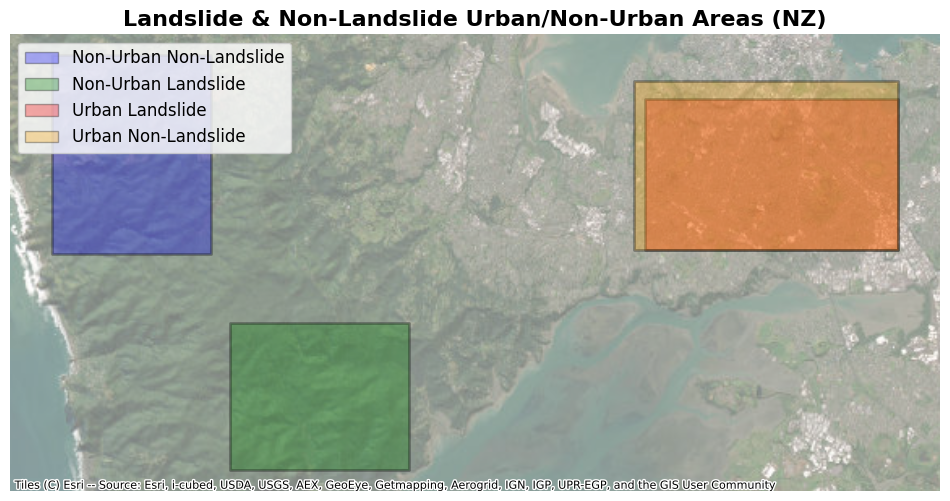

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import contextily as ctx
from matplotlib.patches import Patch

# --- Define bounding boxes ---
areas = {
    "Non-Urban Non-Landslide": [-36.918155, 174.457741, -36.850557, 174.525032],
    "Non-Urban Landslide": [-36.99118, 174.532928, -36.941223, 174.608803],
    "Urban Landslide": [-36.916507, 174.70871, -36.865401, 174.815826],
    "Urban Non-Landslide": [-36.916507, 174.704247, -36.859354, 174.815826]
}

colors = {
    "Non-Urban Non-Landslide": "blue",
    "Non-Urban Landslide": "green",
    "Urban Landslide": "red",
    "Urban Non-Landslide": "orange"
}

# Convert to GeoDataFrame
gdf_list = []
for name, bbox in areas.items():
    min_lat, min_lon, max_lat, max_lon = bbox
    geom = box(min_lon, min_lat, max_lon, max_lat)
    gdf_list.append({'geometry': geom, 'area_type': name})

gdf = gpd.GeoDataFrame(gdf_list, crs="EPSG:4326")

# Project to Web Mercator for basemap
gdf_web = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot bounding boxes first
gdf_web.plot(ax=ax, color=[colors[row.area_type] for _, row in gdf_web.iterrows()],
             alpha=0.3, edgecolor='black', linewidth=2)

# Add basemap with transparency
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, alpha=0.5)

# Title
ax.set_title("Landslide & Non-Landslide Urban/Non-Urban Areas (NZ)", fontsize=16, fontweight='bold')
ax.set_axis_off()

# Legend
legend_elements = [Patch(facecolor=colors[name], edgecolor='black', alpha=0.3, label=name)
                   for name in areas.keys()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True)

# Save as high-res publication figure
output_path = "content/images/areas_basemap_publication.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved publication-ready basemap (transparent): {output_path}")


In [ ]:
import ee
import os
import random
import urllib.request
import numpy as np
from shapely.geometry import Polygon, Point, box
from PIL import Image
from arcgis.gis import GIS
from arcgis.features import FeatureLayer
from pyproj import Transformer
from pyproj import Geod

# --- Initialize Earth Engine ---
try:
    ee.Initialize(project='andy-geog761')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='andy-geog761')

# --- Initialize ArcGIS ---
gis = GIS()

# --- Output folders ---
folders = {
    # "urban_landslide": "./arrays/urban/landslide",
    # "urban_nonlands": "./arrays/urban/nonlandslide",
    # "nonurban_landslide": "./arrays/nonurban/landslide",
    # "nonurban_nonlands": "./arrays/nonurban/nonlandslide"
    "auckland_landslide": "./arrays/auckland/landslide",
    "auckland_nonlands": "./arrays/auckland/nonlandslide",
    "rodney_landslide": "./arrays/rodney/landslide",
    "rodney_nonlands": "./arrays/rodney/nonlandslide",
    "northland_landslide": "./arrays/rodney/landslide",
    "northland_nonlands": "./arrays/rodney/nonlandslide",
}

for f in folders.values():
    os.makedirs(f, exist_ok=True)

# --- Parameters ---
NUM_SAMPLES_MULTIPLIER = 2  # Multiplier for non-landslide samples relative to landslide samples
BUFFER_METERS = 250
PATCH_SIZE = 256  # Fixed size for consistent output
SCALE = 10  # Sentinel-2 resolution
MIN_DISTANCE = 100  # Minimum distance between landslide image centers (meters)

# --- Sentinel-2 collection ---
S2 = (ee.ImageCollection("COPERNICUS/S2_SR")
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .filterDate('2020-01-01', '2023-12-31'))

# --- Fetch landslide polygons from ArcGIS ---
print("📥 Fetching landslide polygons from ArcGIS...")
polygon_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/2"
polygon_layer = FeatureLayer(polygon_url)
polygons = polygon_layer.query(where="1=1", out_fields="*", result_record_count=2000).features

# Transformer from NZTM2000 (EPSG:2193) to WGS84 lat/lon (EPSG:4326)
transformer = Transformer.from_crs("epsg:2193", "epsg:4326", always_xy=True)

# Convert polygons to Shapely polygons (lon, lat)
polygon_shapes = []
for poly in polygons:
    for ring in poly.geometry['rings']:
        coords_lonlat = [transformer.transform(x, y) for x, y in ring]
        polygon_shapes.append(Polygon(coords_lonlat))

print(f"✅ Loaded {len(polygon_shapes)} landslide polygons")

# --- Define search areas (min_lat, min_lon, max_lat, max_lon) ---
areas = {
    # "urban_landslide": [-36.916507, 174.70871, -36.865401, 174.815826],
    # "urban_nonlands": [-36.916507, 174.704247, -36.859354, 174.815826],
    "auckland_landslide": [-36.8, 174.4, -36.953, 174.622],
    "auckland_nonlands": [-36.8, 174.4, -36.953, 174.622],
    "rodney_landslide": [-36.551093, 174.254, -36.61662, 174.34288],
    "rodney_nonlands": [-36.551093, 174.254, -36.61662, 174.34288],
    "northland_landslide": [-36.294428, 174.438, -36.574265, 174.665],
    "northland_nonlands": [-36.294428, 174.438, -36.574265, 174.665]
}

def get_s2_bands_fixed_size(lat, lon, region, out_path):
    """Get Sentinel-2 bands as fixed-size numpy array using getThumbURL."""
    point = ee.Geometry.Point(lon, lat)

    # Get the least cloudy image
    img = (S2.filterBounds(point)
             .sort('CLOUDY_PIXEL_PERCENTAGE')
             .first())

    if img is None:
        print(f"⚠️ No Sentinel-2 image found at ({lat:.5f}, {lon:.5f})")
        return None

    try:
        # Define bands we want
        bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']

        # Download each band individually with fixed size
        band_arrays = []

        for band in bands:
            try:
                # Get URL for this band
                url = img.select([band]).getThumbURL({
                    'region': region,
                    'dimensions': f"{PATCH_SIZE}x{PATCH_SIZE}",
                    'format': 'png',
                    'min': 0,
                    'max': 3000  # Adjust based on typical reflectance values
                })

                # Download the band image
                temp_file = f"temp_{band}_{random.randint(1000, 9999)}.png"
                urllib.request.urlretrieve(url, temp_file)

                # Read as grayscale and convert to numpy array
                band_img = Image.open(temp_file).convert('L')
                band_array = np.array(band_img, dtype=np.float32)

                # Ensure correct shape
                if band_array.shape != (PATCH_SIZE, PATCH_SIZE):
                    # Resize if needed
                    band_img_resized = band_img.resize((PATCH_SIZE, PATCH_SIZE), Image.Resampling.LANCZOS)
                    band_array = np.array(band_img_resized, dtype=np.float32)

                band_arrays.append(band_array)

                # Clean up temp file
                os.remove(temp_file)

            except Exception as e:
                print(f"   Failed to download band {band}: {e}")
                # Create a zero array as fallback
                zero_array = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
                band_arrays.append(zero_array)

        # Stack all bands into a single array (height, width, bands)
        stacked_array = np.stack(band_arrays, axis=-1)

        # Save the array
        np.save(out_path, stacked_array)
        print(f"   ✅ Saved bands array: {stacked_array.shape}")
        return stacked_array

    except Exception as e:
        print(f"⚠️ Failed to extract bands: {e}")
        return None

def random_point_in_box(min_lat, min_lon, max_lat, max_lon):
    """Generate random point within bounding box."""
    lat = random.uniform(min_lat, max_lat)
    lon = random.uniform(min_lon, max_lon)
    return lat, lon

def filter_polygons_in_bbox(polygons, bbox):
    """Filter polygons that intersect with bounding box."""
    min_lat, min_lon, max_lat, max_lon = bbox
    bbox_poly = box(min_lon, min_lat, max_lon, max_lat)
    return [p for p in polygons if p.intersects(bbox_poly)]


def group_nearby_polygons(polygons, min_distance):
    """Group polygons that are close to each other to avoid duplicate images."""
    if not polygons:
        return []

    # Use WGS84 ellipsoid for accurate distance calculation
    geod = Geod(ellps='WGS84')

    grouped_polygons = []
    used_indices = set()

    for i, poly1 in enumerate(polygons):
        if i in used_indices:
            continue

        # Start a new group with this polygon
        group_indices = [i]
        group_polygons = [poly1]
        max_group_distance = 0.0

        for j, poly2 in enumerate(polygons[i+1:], i+1):
            if j in used_indices:
                continue

            # Calculate geodesic distance between polygon centroids in meters
            centroid1 = poly1.centroid
            centroid2 = poly2.centroid

            # Calculate distance in meters
            _, _, distance_meters = geod.inv(
                centroid1.x, centroid1.y,
                centroid2.x, centroid2.y
            )
            distance_meters = abs(distance_meters)  # Ensure positive distance

            # If centroids are close, group them
            if distance_meters <= min_distance:
                group_indices.append(j)
                group_polygons.append(poly2)
                max_group_distance = max(max_group_distance, distance_meters)

        # Mark all grouped polygons as used
        used_indices.update(group_indices)

        # Use the first polygon in the group
        if group_polygons:
            grouped_polygons.append(group_polygons[0])

        if len(group_polygons) > 1:
            print(f"   Grouped {len(group_polygons)} polygons (max distance: {max_group_distance:.1f}m)")

    print(f"   Reduced {len(polygons)} polygons to {len(grouped_polygons)} unique locations")
    return grouped_polygons

# --- Process each area ---
landslide_counts = {}  # Store landslide counts for each area

# First pass: Process landslide areas and count samples
for key, bbox in areas.items():
    if "landslide" in key:
        print(f"\n🔄 Processing {key}...")
        min_lat, min_lon, max_lat, max_lon = bbox

        # Filter polygons within this area
        area_polygons = filter_polygons_in_bbox(polygon_shapes, bbox)
        print(f"Detected {len(area_polygons)} landslide polygons in {key}")

        # Group nearby polygons to avoid duplicate images
        unique_polygons = group_nearby_polygons(area_polygons, MIN_DISTANCE)

        # Store the landslide count for this area (used for non-landslide multiplier)
        area_base = key.replace("_landslide", "")
        landslide_counts[area_base] = len(unique_polygons)

        count = 0
        # --- Landslide samples: one per unique location ---
        for i, poly in enumerate(unique_polygons):
            try:
                centroid = poly.centroid
                region = ee.Geometry.Point(centroid.x, centroid.y).buffer(BUFFER_METERS).bounds()

                # Get band array using existing function
                out_array = os.path.join(folders[key], f"{key}_{i+1}.npy")
                band_array = get_s2_bands_fixed_size(centroid.y, centroid.x, region, out_array)

                if band_array is not None:
                    count += 1
                    print(f"Saved landslide sample {count}/{len(unique_polygons)}")

            except Exception as e:
                print(f"Failed to extract landslide sample {i+1}: {e}")
                continue

        print(f"✅ Done with {key}. Saved {count} samples.")

# Second pass: Process non-landslide areas using multiplier
for key, bbox in areas.items():
    if "nonlands" in key:
        area_base = key.replace("_nonlands", "")
        num_landslide_samples = landslide_counts.get(area_base, 0)
        target_nonlandslide_samples = num_landslide_samples * NUM_SAMPLES_MULTIPLIER

        print(f"\n🔄 Processing {key}...")
        print(f"  Target: {target_nonlandslide_samples} samples ({num_landslide_samples} landslide × {NUM_SAMPLES_MULTIPLIER})")

        min_lat, min_lon, max_lat, max_lon = bbox

        # Filter polygons within this area
        area_polygons = filter_polygons_in_bbox(polygon_shapes, bbox)

        # --- Non-landslide samples: random points ---
        non_count = 0
        attempts = 0
        max_attempts = target_nonlandslide_samples * 10  # Allow more attempts

        while non_count < target_nonlandslide_samples and attempts < max_attempts:
            attempts += 1
            try:
                lat, lon = random_point_in_box(min_lat, min_lon, max_lat, max_lon)
                region = ee.Geometry.Point(lon, lat).buffer(BUFFER_METERS).bounds()

                # Skip regions overlapping landslides
                overlap = False
                for poly in area_polygons:
                    if poly.contains(Point(lon, lat)):
                        overlap = True
                        break
                if overlap:
                    continue

                # Get band array using existing function
                out_array = os.path.join(folders[key], f"{key}_{non_count+1}.npy")
                band_array = get_s2_bands_fixed_size(lat, lon, region, out_array)

                if band_array is not None:
                    non_count += 1
                    print(f"Saved non-landslide sample {non_count}/{target_nonlandslide_samples}")

            except Exception as e:
                print(f"Failed to extract non-landslide sample: {e}")
                continue

        print(f"✅ Done with {key}. Saved {non_count} samples.")

print(f"\n🎉 All band array generation complete!")

/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


📥 Fetching landslide polygons from ArcGIS...
✅ Loaded 2004 landslide polygons

🔄 Processing auckland_landslide...
Detected 28 landslide polygons in auckland_landslide
   Grouped 2 polygons (max distance: 16.7m)
   Grouped 7 polygons (max distance: 90.8m)
   Grouped 5 polygons (max distance: 45.8m)
   Grouped 3 polygons (max distance: 90.2m)
   Grouped 6 polygons (max distance: 63.4m)
   Grouped 3 polygons (max distance: 0.0m)
   Reduced 28 polygons to 8 unique locations
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 1/8
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 2/8
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 3/8
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 4/8
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 5/8
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 6/8
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 7/8
   ✅ Saved bands array: (256, 256, 6)
Saved landslide sample 8/8
✅ Don

KeyboardInterrupt: 

In [ ]:
import os

# Set the folder you want to clear
paths =  ["./arrays/nonurban/landslide", "./arrays/nonurban/nonlandslide"]

# Check if folder exists
for path in paths:
  if os.path.exists(path):
      imgs = os.listdir(path)
      for img in imgs:
          file_path = os.path.join(path, img)
          if os.path.isfile(file_path):
              os.remove(file_path)
      print(f"✅ Deleted {len(imgs)} images from {path}")
  else:
      print(f"⚠️ Path does not exist: {path}")


✅ Deleted 77 images from ./arrays/nonurban/landslide
✅ Deleted 110 images from ./arrays/nonurban/nonlandslide


In [ ]:
!zip -r /content/landslides50.zip /content/arrays/nonurban/landslide
!zip -r /content/nonlandslides50.zip /content/arrays/nonurban/nonlandslide



  adding: content/arrays/nonurban/landslide/ (stored 0%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_5.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_6.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_1.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_17.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_27.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_8.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_10.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_11.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_4.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_26.npy (deflated 98%)
  adding: content/arrays/nonurban/landslide/nonurban_landslide_7.npy (deflated 98%)
  adding: cont

Generated 1360 tile centers
   ✅ Saved bands array: (256, 256, 6)
Tile 0: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 1: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 2: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 3: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 4: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 5: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 6: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 7: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 8: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 9: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 10: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 11: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 12: 0.22
   ✅ Saved bands array: (256, 256, 6)
Tile 13: 0.10
   ✅ Saved bands array: (256, 256, 6)
Tile 14: 0.08
   ✅ Saved bands array: (256, 256, 6)
Tile 15: 0.04
   ✅ Saved bands array: (256, 256, 6)
Tile 16: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 17: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 18:

   ✅ Saved bands array: (256, 256, 6)
Tile 67: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 68: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 69: 0.02
   ✅ Saved bands array: (256, 256, 6)
Tile 70: 0.03
   ✅ Saved bands array: (256, 256, 6)
Tile 71: 0.04
   ✅ Saved bands array: (256, 256, 6)
Tile 72: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 73: 0.02
   ✅ Saved bands array: (256, 256, 6)
Tile 74: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 75: 0.00
   Failed to download band B8: HTTP Error 503: Service Unavailable
   ✅ Saved bands array: (256, 256, 6)
Tile 76: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 77: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 78: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 79: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 80: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 81: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 82: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 83: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 84: 0.

   ✅ Saved bands array: (256, 256, 6)
Tile 157: 0.03
   ✅ Saved bands array: (256, 256, 6)
Tile 158: 0.05
   ✅ Saved bands array: (256, 256, 6)
Tile 159: 0.02
   ✅ Saved bands array: (256, 256, 6)
Tile 160: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 161: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 162: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 163: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 164: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 165: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 166: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 167: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 168: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 169: 0.06
   ✅ Saved bands array: (256, 256, 6)
Tile 170: 0.14
   ✅ Saved bands array: (256, 256, 6)
Tile 171: 0.13
   ✅ Saved bands array: (256, 256, 6)
Tile 172: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 173: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 174: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 175

   ✅ Saved bands array: (256, 256, 6)
Tile 181: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 182: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 183: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 184: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 185: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 186: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 187: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 188: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 189: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 190: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 191: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 192: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 193: 0.04
   ✅ Saved bands array: (256, 256, 6)
Tile 194: 0.43
   ✅ Saved bands array: (256, 256, 6)
Tile 195: 0.08
   ✅ Saved bands array: (256, 256, 6)
Tile 196: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 197: 0.04
   ✅ Saved bands array: (256, 256, 6)
Tile 198: 0.02
   ✅ Saved bands array: (256, 256, 6)
Tile 199

   ✅ Saved bands array: (256, 256, 6)
Tile 384: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 385: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 386: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 387: 0.02
   ✅ Saved bands array: (256, 256, 6)
Tile 388: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 389: 0.07
   ✅ Saved bands array: (256, 256, 6)
Tile 390: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 391: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 392: 0.01
   ✅ Saved bands array: (256, 256, 6)
Tile 393: 0.04
   ✅ Saved bands array: (256, 256, 6)
Tile 394: 0.44
   ✅ Saved bands array: (256, 256, 6)
Tile 395: 0.42
   ✅ Saved bands array: (256, 256, 6)
Tile 396: 0.04
   ✅ Saved bands array: (256, 256, 6)
Tile 397: 0.34
   ✅ Saved bands array: (256, 256, 6)
Tile 398: 0.02
   ✅ Saved bands array: (256, 256, 6)
Tile 399: 0.04
   ✅ Saved bands array: (256, 256, 6)
Tile 400: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 401: 0.00
   ✅ Saved bands array: (256, 256, 6)
Tile 402

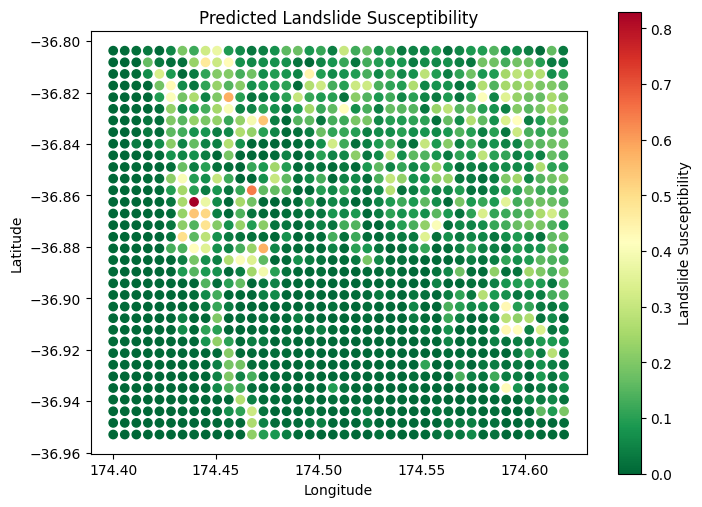

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import joblib
from matplotlib.colors import ListedColormap
from PIL import Image

# Load trained Random Forest
rf_model = joblib.load('rf_model.pkl')

# Load patch arrays and predict
def classify_tile(tile_path, model):
    """Classify a single Sentinel-2 tile (6-band numpy array)."""
    arr = np.load(tile_path)
    # Flatten pixels to feed into the model
    X = arr.reshape(-1, arr.shape[-1])
    preds = model.predict_proba(X)[:, 1]  # probability of landslide
    pred_mask = preds.reshape(arr.shape[:2])
    return pred_mask

# Overlay prediction mask on RGB
def overlay_prediction(rgb_array, pred_mask, alpha=0.5):
    """Overlay probability mask on RGB Sentinel-2 image."""
    # Normalize RGB for display
    rgb_vis = np.clip(rgb_array / np.percentile(rgb_array, 99), 0, 1)

    # Create color map (green = safe, red = landslide)
    cmap = ListedColormap([[0, 1, 0, 0], [1, 0, 0, alpha]])  # transparent green→red

    plt.figure(figsize=(6,6))
    plt.imshow(rgb_vis)
    plt.imshow(pred_mask, cmap='Reds', alpha=alpha)
    plt.axis('off')
    plt.title("Landslide Susceptibility Overlay")
    plt.show()

# Example usage:
tile_path = "./arrays/manukau/landslide/manukau_landslide_1.npy"
arr = np.load(tile_path)

# Extract RGB bands (B4, B3, B2)
rgb_array = arr[:, :, [2, 1, 0]]
pred_mask = classify_tile(tile_path, rf_model)

overlay_prediction(rgb_array, pred_mask)
